In [1]:
library(tidyverse)
library(cowplot)

stage_colors <- c(immature = "#93C572", mature = "#3F7A43")
outline      <- "grey25"

theme_set(theme_cowplot(font_size = 12))
options(repr.plot.width = 8, repr.plot.height = 4.5)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
areas <- read_csv("data/gland_areas.csv", show_col_types = FALSE)

areas$stage <- factor(areas$stage, levels = c("immature", "mature"))

areas %>%
  mutate(diameter_um = 2 * sqrt(area_um2 / pi)) -> areas

areas

stage,image,area_um2,diameter_um
<fct>,<chr>,<dbl>,<dbl>
immature,istb50x,64938.88,287.5461
immature,istb50x,43365.07,234.9769
immature,istb50x,56210.56,267.5248
immature,istb50x,49896.81,252.0528
immature,istb50x,71646.52,302.0318
immature,istb50x,34248.09,208.8206
immature,istb50x,56208.99,267.5210
immature,istb50x,43686.57,235.8463
immature,istb50x,34296.44,208.9679


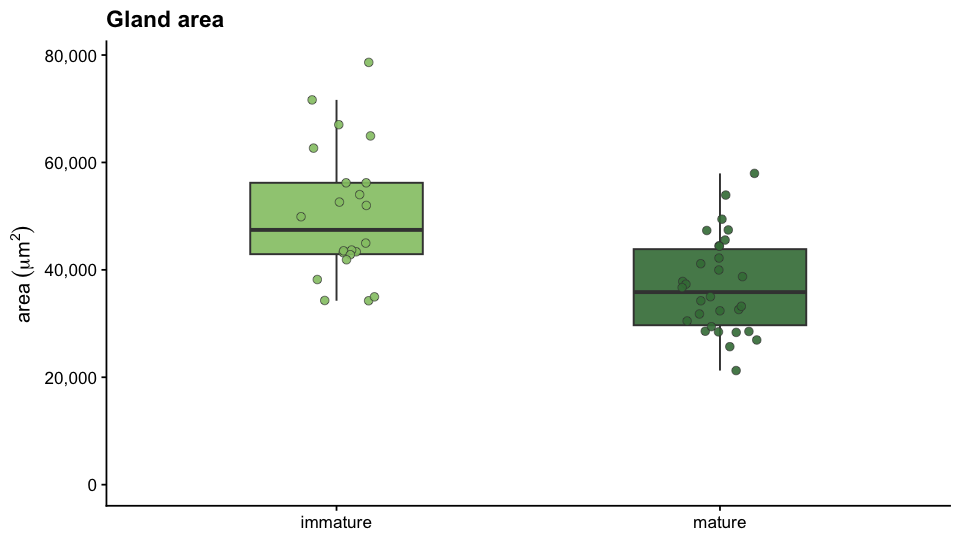

In [3]:
plot1 <- ggplot(areas, aes(x = stage, y = area_um2, fill = stage)) +
  geom_boxplot(width = 0.45, outlier.shape = NA, alpha = 0.9, colour = outline) +
  geom_jitter(shape = 21, width = 0.10, size = 2.2, stroke = 0.3,
              colour = outline, alpha = 0.9) +
  scale_fill_manual(values = stage_colors) +
  scale_y_continuous(limits = c(0, NA), labels = scales::comma) +
  labs(title = "Gland area", x = NULL, y = expression(area~(mu*m^2))) +
  theme(legend.position = "none")

plot1
ggsave("output/gland_area.png", plot1, width = 6, height = 4.5, dpi = 300)

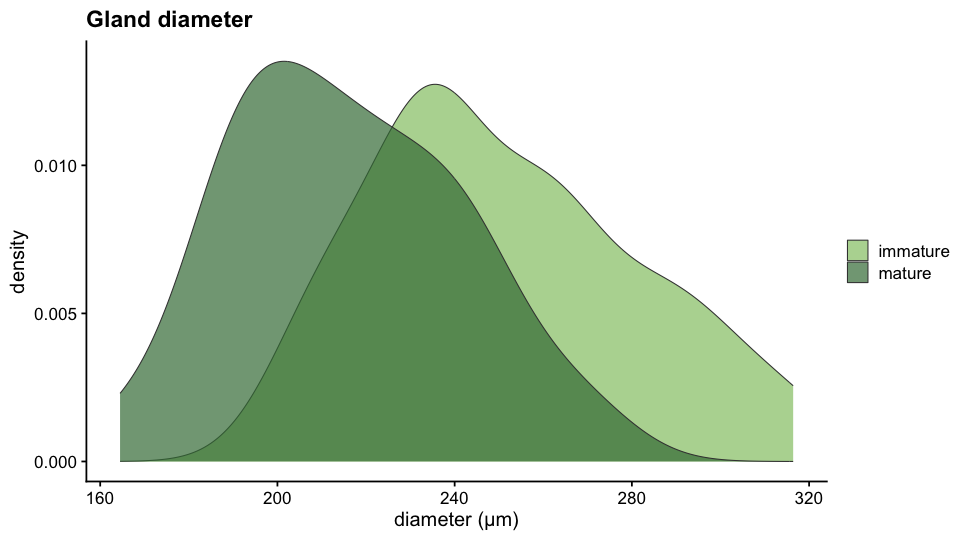

In [4]:
plot2 <- ggplot(areas, aes(x = diameter_um, fill = stage)) +
  geom_density(alpha = 0.7, colour = outline, linewidth = 0.3) +
  scale_fill_manual(values = stage_colors) +
  labs(title = "Gland diameter", x = "diameter (µm)", y = "density", fill = NULL)

plot2
ggsave("output/gland_diameter.png", plot2, width = 7, height = 4.5, dpi = 300)

In [5]:
areas %>%
  group_by(stage) %>%
  summarise(
    n         = n(),
    mean_area = mean(area_um2),
    sd_area   = sd(area_um2),
    median    = median(area_um2),
    mean_diam = mean(diameter_um)
  ) -> summary_table

as.data.frame(summary_table)

stage,n,mean_area,sd_area,median,mean_diam
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
immature,22,50502.92,12410.371,47439.37,251.8184
mature,30,37045.73,8901.813,35853.50,215.6915


In [6]:
areas %>% filter(stage == "immature") %>% pull(area_um2) -> immature_areas
areas %>% filter(stage == "mature")   %>% pull(area_um2) -> mature_areas

wilcox.test(immature_areas, mature_areas)


	Wilcoxon rank sum exact test

data:  immature_areas and mature_areas
W = 536, p-value = 7.342e-05
alternative hypothesis: true location shift is not equal to 0
